# The controller

Sources in, sinks out, feedback loops of prefilter, measure, estimator and regulator between; a panel; saved.

## 1 Setup

In [1]:
from coaxial import EMULATED, HARDWARE, SIMULATED

MODE = SIMULATED          # HARDWARE, and PORT, at the bench; EMULATED: the image on Renode
PORT = 'COM4'

## 2 Source and sink

The application's IO is an array of nodes, discovered; the first board's drive runs on the model. Ask what it offers, then build the loop over its `drive` module: `<node>.drive.omega_hat` in, `<node>.drive.iq_ref` out, every channel a float.

In [2]:
from motor.pmsm import RAD_S_PER_RPM, Parameters
from machine import ansi
from machine.controller import Feedback, Loop, Paced
from machine.nodes import Nodes
from machine.parts import Gain, LowPass, Slew, SpeedKalman, SpeedPI
from machine.wiring import feedback

J, B = 2e-5, 1e-5
nodes = Nodes.discover(port=PORT, execution_mode=MODE, peripherals=())
node = nodes.of_type('bldc_inverter')[0]
at = node.name + '.drive'
drive, gates = node.rig.drive, node.rig.gates
drive.configure(source='model')
drive.model.configure(j=J, b=B, load=0.0, noise=0.05)
gates.on(bypass_sto=True, ignore_interlock=True)
drive.write(id_ref=0.0, iq_ref=0.0)
drive.on('sensorless')

p = drive.params()
poles = int(p['motor_pole_pairs'])
motor = Parameters(name='the record', r=p['motor_r'], ld=p['motor_ld'],
                   lq=p['motor_lq'], lam=p['motor_lambda'], poles=poles, j=J, b=B,
                   measured=False)
kt = 1.5 * poles * motor.lam
print('%d nodes; %s drives the loop' % (len(nodes), node.name))
print(Nodes([node]).card('drive', keys=('omega_hat', 'iq', 'vdc', 'id_ref', 'iq_ref', 'theta')))
loop = nodes.loop(inputs=[at], outputs=[at], rate_hz=25)

20 nodes; AX_1 drives the loop
AX_1: bldc_inverter coaxial_63100, AX unit 1
  in  drive.iq A, drive.omega_hat rad/s, drive.vdc V
  out drive.id_ref A -5..5, drive.iq_ref A -5..5, drive.theta rad


## 3 A feedback loop

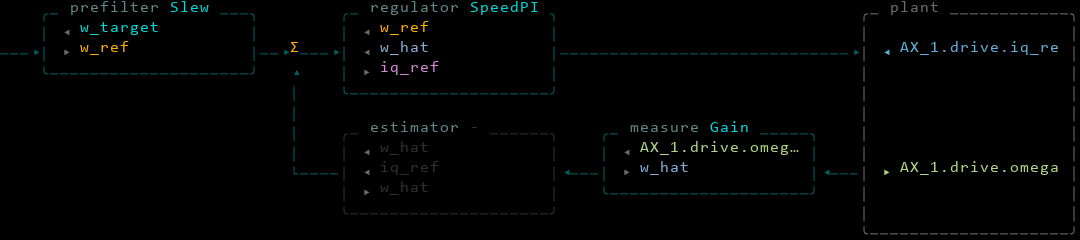

In [3]:
loop.add('speed', Feedback(
    SpeedPI.of(3.0, 2.0, motor), setpoint='w_target', measured=at + '.omega_hat',
    command='iq_ref', sink=at + '.iq_ref', prefilter=Slew(1500 * RAD_S_PER_RPM),
    measure=Gain(1.0 / poles), ref='w_ref', value='w_hat'))
ansi.image(feedback(loop, 'speed'))

In [4]:
rows = loop.move(2.0, w_target=1000 * RAD_S_PER_RPM)
for r in rows[::10]:
    print('%5.2f s  w_ref %6.0f  w_hat %6.0f rpm  iq %6.3f A'
          % (r['t'], r['w_ref'] / RAD_S_PER_RPM, r['w_hat'] / RAD_S_PER_RPM, r['iq_ref']))

 0.00 s  w_ref      0  w_hat      0 rpm  iq  0.060 A
 0.41 s  w_ref    608  w_hat    593 rpm  iq  0.084 A
 0.81 s  w_ref   1000  w_hat    999 rpm  iq  0.023 A
 1.21 s  w_ref   1000  w_hat    995 rpm  iq  0.027 A
 1.62 s  w_ref   1000  w_hat    996 rpm  iq  0.027 A


## 4 An estimator in its slot

The stand-in's speed carries no noise, so the measure slot gets a sensor of your own that adds some: a `Filter` is `step(dt, x) -> {'y': ...}`. `SpeedKalman` predicts on the command, corrects on the measurement: `w` raw, `w_hat` estimated, one run.

spread at 1000 rpm: measured 15.79 rpm, estimated 4.17 rpm


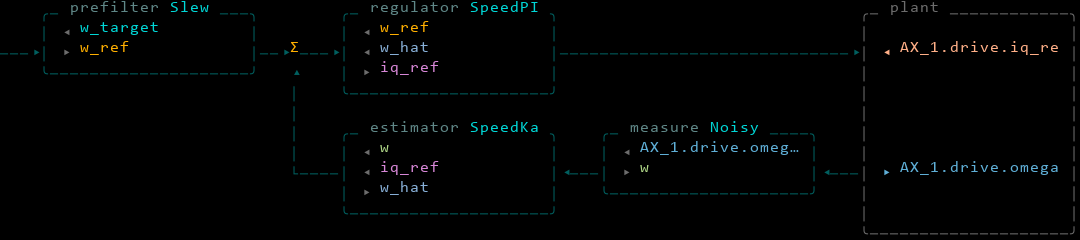

In [5]:
import random
from machine.roles import Filter

def spread(values):
    m = sum(values) / len(values)
    return (sum((v - m) ** 2 for v in values) / len(values)) ** 0.5

class Noisy(Filter):
    """A speed sensor: the scaled speed, and gaussian noise of `rms` on it."""
    PARAMS = ('k', 'rms')

    def __init__(self, k=1.0, rms=5.0):
        self.k, self.rms, self.rng = k, rms, random.Random(1)

    def step(self, dt, x=0.0):
        return {'y': self.k * x + self.rng.gauss(0.0, self.rms)}

NOISE = 20.0 * RAD_S_PER_RPM

def kalman():
    """r the sensor's variance; q small: the rotor's law predicts well."""
    return SpeedKalman(kt, J, B, q=10.0, r=NOISE ** 2)

f = loop.feedbacks['speed']
f.measure = Noisy(1.0 / poles, NOISE)
f.estimator, f.value, f.estimate = kalman(), 'w', 'w_hat'
loop.add('speed', f)
held = loop.run(1.5)[-20:]
raw, estimated = (spread([r[k] / RAD_S_PER_RPM for r in held]) for k in ('w', 'w_hat'))
print('spread at 1000 rpm: measured %.2f rpm, estimated %.2f rpm' % (raw, estimated))
ansi.image(feedback(loop, 'speed'))

## 5 Another prefilter

0 to 2000 rpm through `Slew` (1500 rpm/s), then `LowPass` (0.3 s): a low-pass starts steep and ends soft, so it asks more peak current and has no corner.

In [6]:
def peak(rows):
    return max(abs(r['iq_ref']) for r in rows)

loop.move(2.0, w_target=0.0)
slewed = peak(loop.move(1.5, w_target=2000 * RAD_S_PER_RPM))
loop.move(2.0, w_target=0.0)
f.prefilter = LowPass(0.3)
loop.add('speed', f)
lowpassed = peak(loop.move(1.5, w_target=2000 * RAD_S_PER_RPM))
print('peak iq to 2000 rpm: Slew %.3f A, LowPass %.3f A' % (slewed, lowpassed))

peak iq to 2000 rpm: Slew 0.158 A, LowPass 0.266 A


## 6 A part at its own pace

`Paced` steps a part on its own thread; `feed` hands it fresh inputs between the loop's passes. The estimator at 100 Hz under a 10 Hz loop.

In [7]:
fast = Paced(kalman(), 100,
             feed=lambda: {'measured': drive.state()['omega_hat'] / poles})
f.estimator = fast
loop.add('speed', f)
loop.pause = 0.1
passes = len(loop.run(1.5))
print('%d estimator steps under %d loop passes' % (fast.steps, passes))
fast.stop()
f.estimator = kalman()
loop.add('speed', f)
loop.pause = 0.04

145 estimator steps under 15 loop passes


## 7 A regulator of your own

A `Regulator` names its PARAMS and steps: `step(dt, setpoint, measured)` -> `{'command': ...}`. Proportional alone leaves the drag as its error.

In [8]:
from machine.roles import Regulator

class Proportional(Regulator):
    PARAMS = ('kp', 'limit')

    def __init__(self, kp=2e-3, limit=2.0):
        self.kp, self.limit = kp, limit

    def step(self, dt, setpoint=0.0, measured=0.0):
        u = self.kp * (setpoint - measured)
        return {'command': max(-self.limit, min(self.limit, u))}

def error(rows):
    return 1000 - sum(r['w_hat'] for r in rows[-10:]) / 10 / RAD_S_PER_RPM

f.regulator = Proportional()
loop.add('speed', f)
p_error = error(loop.move(2.0, w_target=1000 * RAD_S_PER_RPM))
f.regulator = SpeedPI.of(3.0, 2.0, motor)
loop.add('speed', f)
pi_error = error(loop.move(2.0, w_target=1000 * RAD_S_PER_RPM))
print('error at 1000 rpm: Proportional %.0f rpm, SpeedPI %.0f rpm' % (p_error, pi_error))

error at 1000 rpm: Proportional 95 rpm, SpeedPI 25 rpm


## 8 The panel, and kept

The loops in a list with + and -; the selected one drawn, its channels, kinds and parameters in dropdowns and fields, live. `save` writes the loop; `Loop.load` rebuilds it on live sources and sinks.

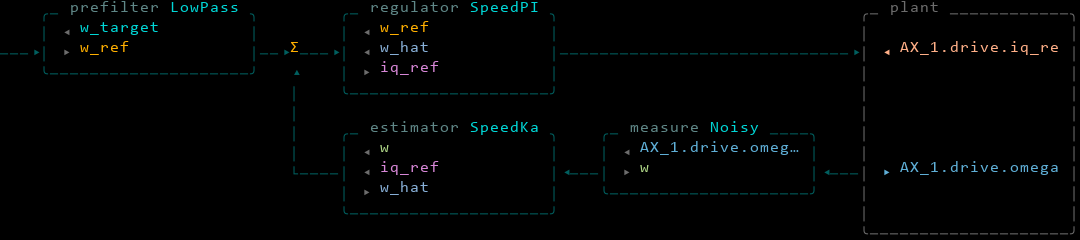

In [9]:
import os
import tempfile
from machine.panel import panel

path = os.path.join(tempfile.gettempdir(), 'coaxial_controller.json')
loop.save_at_exit(path)
panel(loop, path)

In [10]:
loop.save(path)
again = Loop.load(path, loop.sources, loop.sinks)
kept = again.config() == loop.config()
print('saved %s: %d loop, %d parts, reloaded the same: %s'
      % (os.path.basename(path), len(again.feedbacks), len(again.parts), kept))
loop.move(1.0, w_target=0.0)
loop.off()
gates.off()
print('back on the converters:', drive.configure(source='adc')['source'])
nodes.close()

saved coaxial_controller.json: 1 loop, 4 parts, reloaded the same: True


back on the converters: True


## 9 Results

In [11]:
print('1. estimate spread    measured %.2f rpm, SpeedKalman %.2f rpm' % (raw, estimated))
print('2. peak current       Slew %.3f A, LowPass %.3f A' % (slewed, lowpassed))
print('3. paced              %d estimator steps under %d loop passes' % (fast.steps, passes))
print('4. steady error       Proportional %.0f rpm, SpeedPI %.0f rpm' % (p_error, pi_error))
print('5. kept               %s' % kept)

1. estimate spread    measured 15.79 rpm, SpeedKalman 4.17 rpm
2. peak current       Slew 0.158 A, LowPass 0.266 A
3. paced              145 estimator steps under 15 loop passes
4. steady error       Proportional 95 rpm, SpeedPI 25 rpm
5. kept               True


- `motion.velocity` is this loop: one feedback, `speed`.
- A paced part with a `feed` reads the link between the loop's passes.

**Bench.** The record commissioned first (`commissioning.ipynb`); no flags on `gates.on()`. At the bench `r` is the observer's measured variance.

## References

* `host/machine/controller.py` - `Loop`, `Feedback`, `Paced`, `Polled`; save and load
* `host/machine/nodes.py` - `Nodes`: `card`, and `loop` over their modules
* `host/machine/parts.py` - the parts: Gain, Slew, LowPass, SpeedKalman, PI, SpeedPI
* `host/machine/panel.py` - the panel
* `host/machine/wiring.py` - the pictures: a loop, a feedback
* `host/machine/roles.py` - the roles, and Part: ports, PARAMS, step
* `host/tests/test_controller.py` - the loop against a toy rotor and the stand-in